## XGBoost

XGBoost = eXtreme Gradient Boosting 
Like AdaBoost, it creates models sequentially. But it also uses gradient boosting, which is more sophisticated than AdaBoost. 

Each new tree attempts to improve the errors made by the previous ensemble. 

In [1]:
from pathlib import Path 

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 

import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from src.temporal_cv import(
    validation_years,
    create_temporal_folds
)

from src.evaluation import (
    evaluate_model
)

from xgboost import XGBClassifier

from sklearn.metrics import ( 
    classification_report,  
    ConfusionMatrixDisplay, 
)

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = ( PROCESSED_DATA_DIR / "feature_split_matches.csv")

matches = pd.read_csv(
    input_file, parse_dates=["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)

print(matches["DataSplit"].value_counts())

Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [3]:
#recover training, validation and test set
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

#print periods
print( 
    "Training:", 
    train_data["Date"].min(), 
    "-", 
    train_data["Date"].max()
)

print(
    "Validation:", 
    validation_data["Date"].min(),
    "-", 
    validation_data["Date"].max()
)

print(
    "Test:", 
    test_data["Date"].min(), 
    "-", 
    test_data["Date"].max()
)

Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validation: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Test: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [4]:
#verify chronological ordering
assert(
    train_data["Date"].max() < validation_data["Date"].min()
)

assert(
    validation_data["Date"].max() < test_data["Date"].min()
)

print("Chronological order is maintained.")

Chronological order is maintained.


In [5]:
#check features
print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw selected features:",
    len(numeric_features)
    + len(categorical_features)
)

Numerical features: 30
Categorical features: 5
Raw selected features: 35


**Create the temporal cross-validation folds**

In [6]:
# inside the 2015-2022 development training period.

temporal_folds = create_temporal_folds(
    train_data,
    validation_years
)

print(
    "Number of temporal folds:",
    len(temporal_folds)
)

pd.DataFrame(temporal_folds)

Number of temporal folds: 4


,Fold,TrainingMatches,ValidationMatches,TrainingStartYear,TrainingEndYear,ValidationYear
0,1,10135,2497,2015,2018,2019
1,2,12632,1231,2015,2019,2020
2,3,13863,2402,2015,2020,2021
3,4,16265,2545,2015,2021,2022


**Define XGBoost Configurations**
Tuning of 3 parameters: 
- max_depth = each individual tree can grow to a maximum depth of 2 or 3 (we choose a small depth because with boosting we need relatively small trees)
- n_estimators = build up to 100/200 trees sequentially
- learning_rate = controls how strongly each new tree contributes 
    - small learning rate means: each tree makes a small correction 
    - large learning rate means: each tree makes a stronger correction 

relationship preferred is: small learning rate + more estimator because it produces a more controlled learning rate. 

In [7]:
configurations = [
    {
        "name": "XGBoost depth 2 est 100 lr 0.05", 
        "n_estimators": 100, 
        "max_depth": 2, 
        "learning_rate": 0.05
    },
    {
        "name": "XGBoost depth 2 est 200 lr 0.05", 
        "n_estimators": 200, 
        "max_depth": 2, 
        "learning_rate": 0.05
    },
    {
        "name": "XGBoost depth 2 est 100 lr 0.10", 
        "n_estimators": 100, 
        "max_depth": 2, 
        "learning_rate": 0.10
    },
    {
        "name": "XGBoost depth 2 est 200 lr 0.10", 
        "n_estimators": 200, 
        "max_depth": 2, 
        "learning_rate": 0.10
    },
    {
        "name": "XGBoost depth 3 est 100 lr 0.05", 
        "n_estimators": 100, 
        "max_depth": 3, 
        "learning_rate": 0.05
    },
    {
        "name": "XGBoost depth 3 est 200 lr 0.05", 
        "n_estimators": 200, 
        "max_depth": 3, 
        "learning_rate": 0.05
    },
    {
        "name": "XGBoost depth 3 est 100 lr 0.10", 
        "n_estimators": 100, 
        "max_depth": 3, 
        "learning_rate": 0.10
    },
    {
        "name": "XGBoost depth 3 est 200 lr 0.10", 
        "n_estimators": 200, 
        "max_depth": 3, 
        "learning_rate": 0.10
    },
    
]

In [8]:
#we created 8 configurations so len == 8 
print("Configurations:", len(configurations))

Configurations: 8


Create the result list to store the temporal-cv folders 

In [9]:
xgboost_cv_results = []


for configuration in configurations:

    print("Testing XGBoost:", configuration["name"] )

    # Evaluate the current configuration on all four temporal folds.
    for fold in temporal_folds:

        fold_number = fold["Fold"]
        validation_year = fold["ValidationYear"]


        print(
            "Fold",
            fold_number,
            "- validation year:",
            validation_year
        )

        # Training contains all matches before the current validation year.

        fold_train = train_data.loc[
            train_data["Date"].dt.year
            < validation_year
        ].copy()

        # Validation contains only matches fromthe current validation year.
        fold_validation = train_data.loc[
            train_data["Date"].dt.year
            == validation_year
        ].copy()

        # Every temporal fold gets its own preprocessing.
        # This prevents future information from entering an earlier validation year.
        (
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        ) = fit_preprocessor(
            fold_train
        )

        #transform

        X_fold_train = transform_data(
            fold_train,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )


        X_fold_validation = transform_data(
            fold_validation,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )


        # Targets.

        y_fold_train = (
            fold_train[
                "Player1Won"
            ].to_numpy()
        )

        y_fold_validation = (
            fold_validation[
                "Player1Won"
            ].to_numpy()
        )

        #build model

        current_model = XGBClassifier(
            n_estimators=configuration["n_estimators"], #number of trees
            max_depth=configuration["max_depth"],#complexity of each tree
            learning_rate=configuration["learning_rate"],#how strongly each new tree corrects the ensemble
            
            #our problem has 2 possible outcomes
            # 0=Player2 wins / 1=Player1Wins
            #objective tells the XGBoost to produce prob for this binary outcome
            objective="binary:logistic",
            
            #we care about logloss --> lower logloss = better
            # logloss evaluates not only wether a prediction is right, 
            # but also how confident the model was
            eval_metric="logloss",
            
            #useful for feature importance later
            # it tells us the improvement provided by a feature
            # when used in a tree split
            importance_type="gain",
            
            random_state=42,
            
            # Use all available CPU cores.
            n_jobs=-1
        )


        #train
        current_model.fit( X_fold_train, y_fold_train)


        #predict temporal validation fold
        current_predictions = ( current_model.predict( X_fold_validation))

        # Probability that Player 1 wins.
        current_probabilities = (current_model.predict_proba( X_fold_validation)[:, 1])
        
        #evaluate
        current_fold_results = evaluate_model(
            y_true=y_fold_validation,
            y_pred=current_predictions,
            model_name= configuration["name"],
            y_probability= current_probabilities
        )

        # evaluate_model returns a one-row DataFrame.
        # Convert it into one dictionary.
        current_fold_result = (current_fold_results.iloc[0].to_dict())


        # Add information identifying the fold.

        current_fold_result[
            "Fold"
        ] = fold_number

        current_fold_result[
            "ValidationYear"
        ] = validation_year
        
        current_fold_result[
            "MaxDepth"
        ] = configuration["max_depth"]
        
        current_fold_result[
            "NEstimators"
        ] = configuration["n_estimators"]
        
        current_fold_result[
            "LearningRate"
        ] = configuration["learning_rate"]


        # Store the result.

        xgboost_cv_results.append(
            current_fold_result
        )


        print(
            "Accuracy:",
            round(current_fold_result["Accuracy"], 4)
        )

Testing XGBoost: XGBoost depth 2 est 100 lr 0.05
Fold 1 - validation year: 2019
Accuracy: 0.6344
Fold 2 - validation year: 2020
Accuracy: 0.6385
Fold 3 - validation year: 2021
Accuracy: 0.6391
Fold 4 - validation year: 2022
Accuracy: 0.6519
Testing XGBoost: XGBoost depth 2 est 200 lr 0.05
Fold 1 - validation year: 2019
Accuracy: 0.632
Fold 2 - validation year: 2020
Accuracy: 0.6385
Fold 3 - validation year: 2021
Accuracy: 0.642
Fold 4 - validation year: 2022
Accuracy: 0.6582
Testing XGBoost: XGBoost depth 2 est 100 lr 0.10
Fold 1 - validation year: 2019
Accuracy: 0.6372
Fold 2 - validation year: 2020
Accuracy: 0.6401
Fold 3 - validation year: 2021
Accuracy: 0.6395
Fold 4 - validation year: 2022
Accuracy: 0.6527
Testing XGBoost: XGBoost depth 2 est 200 lr 0.10
Fold 1 - validation year: 2019
Accuracy: 0.6288
Fold 2 - validation year: 2020
Accuracy: 0.6271
Fold 3 - validation year: 2021
Accuracy: 0.6399
Fold 4 - validation year: 2022
Accuracy: 0.6597
Testing XGBoost: XGBoost depth 3 est 1

In [10]:
xgboost_cv_fold_results = pd.DataFrame(
    xgboost_cv_results
)

xgboost_cv_fold_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss,Fold,ValidationYear,MaxDepth,NEstimators,LearningRate
0,XGBoost depth 2 est 100 lr 0.05,0.634361,0.634123,0.638298,0.605816,0.621633,0.690675,0.633001,1,2019,2,100,0.05
1,XGBoost depth 2 est 100 lr 0.05,0.638505,0.638940,0.659539,0.627543,0.643144,0.703800,0.624353,2,2020,2,100,0.05
2,XGBoost depth 2 est 100 lr 0.05,0.639051,0.638290,0.625219,0.619254,0.622222,0.694307,0.629615,3,2021,2,100,0.05
3,XGBoost depth 2 est 100 lr 0.05,0.651866,0.651651,0.659091,0.619462,0.638662,0.715425,0.617575,4,2022,2,100,0.05
4,XGBoost depth 2 est 200 lr 0.05,0.631958,0.631774,0.633921,0.609855,0.621655,0.689173,0.633628,1,2019,2,200,0.05
5,XGBoost depth 2 est 200 lr 0.05,0.638505,0.639810,0.667241,0.605634,0.634947,0.708077,0.621673,2,2020,2,200,0.05
6,XGBoost depth 2 est 200 lr 0.05,0.641965,0.641359,0.627281,0.626193,0.626736,0.699987,0.625594,3,2021,2,200,0.05
7,XGBoost depth 2 est 200 lr 0.05,0.658153,0.657918,0.666949,0.622627,0.644026,0.718101,0.615006,4,2022,2,200,0.05
8,XGBoost depth 2 est 100 lr 0.10,0.637165,0.637024,0.637874,0.620355,0.628993,0.689131,0.633539,1,2019,2,100,0.10
9,XGBoost depth 2 est 100 lr 0.10,0.640130,0.641499,0.669550,0.605634,0.635990,0.707279,0.622325,2,2020,2,100,0.10


In [11]:
print("Number of cv experiments", len(xgboost_cv_fold_results))

##shoudl be 8*4=32
assert len(xgboost_cv_fold_results) == len(configurations)*len(temporal_folds)

Number of cv experiments 32


**Calculate mean temporal-CV performance**

In [12]:
xgboost_cv_summary = xgboost_cv_fold_results.groupby(
    [
        "Model",
        "MaxDepth",
        "NEstimators",
        "LearningRate"   
    ], 
    as_index=False
    
).agg(
        MeanAccuracy = ("Accuracy", "mean"),
        StdAccuracy = ("Accuracy", "std"),
        MeanBalancedAccuracy = ("BalancedAccuracy", "mean"),
        MeanF1Score = ("F1", "mean"),
        MeanROC_AUC = ("ROC-AUC", "mean"),
        MeanLogLoss = ("LogLoss", "mean")
)

In [13]:

xgboost_cv_summary = xgboost_cv_summary.sort_values(
    by=["MeanAccuracy", "MeanROC_AUC"],
    ascending=[False, False]
).reset_index(drop=True)

xgboost_cv_summary

,Model,MaxDepth,NEstimators,LearningRate,MeanAccuracy,StdAccuracy,MeanBalancedAccuracy,MeanF1Score,MeanROC_AUC,MeanLogLoss
0,XGBoost depth 2 est 200 lr 0.05,2,200,0.05,0.642645,0.011140,0.642715,0.631841,0.703835,0.623975
1,XGBoost depth 2 est 100 lr 0.10,2,100,0.10,0.642353,0.006982,0.642437,0.631549,0.703733,0.623957
2,XGBoost depth 3 est 100 lr 0.10,3,100,0.10,0.641884,0.012208,0.641955,0.631416,0.703743,0.623992
3,XGBoost depth 3 est 200 lr 0.05,3,200,0.05,0.641868,0.011852,0.641994,0.629348,0.703586,0.623634
4,XGBoost depth 3 est 100 lr 0.05,3,100,0.05,0.641648,0.008827,0.641551,0.627436,0.703616,0.623498
5,XGBoost depth 2 est 100 lr 0.05,2,100,0.05,0.640946,0.007575,0.640751,0.631415,0.701052,0.626136
6,XGBoost depth 3 est 200 lr 0.10,3,200,0.10,0.640895,0.011017,0.640892,0.630204,0.698423,0.628787
7,XGBoost depth 2 est 200 lr 0.10,2,200,0.10,0.638874,0.015012,0.638989,0.626855,0.703873,0.624160


Select the best configuration and store it in best model

In [14]:
best_model_name = (xgboost_cv_summary.iloc[0]["Model"])
print("Selected XGBoost:", best_model_name)

Selected XGBoost: XGBoost depth 2 est 200 lr 0.05


In [15]:
#store and print the complete parameter dictionary of the best model

best_configuration = next(
    configuration
    for configuration in configurations 
    if configuration["name"]== best_model_name
)

best_configuration

{'name': 'XGBoost depth 2 est 200 lr 0.05',
 'n_estimators': 200,
 'max_depth': 2,
 'learning_rate': 0.05}

**Fit preprocessing on all training data**
Now hyperparameter tuning is finished. 
We can use the complete 2015-2022 training set. 

In [16]:
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

y_train = train_data["Player1Won"].to_numpy()
y_validation = validation_data["Player1Won"].to_numpy()

In [17]:
print("Training X:", X_train.shape)
print("Validation X:", X_validation.shape)
print("Training y:", y_train.shape)
print("Validation y:", y_validation.shape)

assert X_train.shape[1] == 50
assert X_validation.shape[1] == 50

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

print(
    "Random Forest preprocessing check passed."
)

Training X: (18810, 50)
Validation X: (2607, 50)
Training y: (18810,)
Validation y: (2607,)
Random Forest preprocessing check passed.


**Create the selected XGBoost**

In [18]:
best_model = XGBClassifier(
    n_estimators=best_configuration["n_estimators"],
    max_depth=best_configuration["max_depth"],
    learning_rate=best_configuration["learning_rate"],
    objective="binary:logistic",
    eval_metric="logloss",
    importance_type="gain",
    random_state=42,
    n_jobs=-1
)

In [19]:
# Train the selected configuration using the complete 2015-2022 model-development training period.

best_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
# classification report

best_validation_predictions = (
    best_model.predict(X_validation)
) # returns predicted classes [0, 1, 1, 0, 1, ...]

best_validation_probabilities = (
    best_model.predict_proba(X_validation)[:, 1]
) # returns probabilities that player 1 wins [0.23, 0.81, ...]

print(
    classification_report(
        y_validation, 
        best_validation_predictions, 
        target_names=["Player 2 wins", "Player 1 wins"], 
        zero_division=0
    ) # compares true validation labels against predicted validation labels
)

               precision    recall  f1-score   support

Player 2 wins       0.66      0.63      0.65      1368
Player 1 wins       0.61      0.64      0.63      1239

     accuracy                           0.64      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.64      0.64      0.64      2607



In [21]:
best_xgboost_result= evaluate_model(
    y_true=y_validation,
    y_pred=best_validation_predictions,
    model_name=best_model_name,
    y_probability=best_validation_probabilities
)

best_xgboost_result

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,XGBoost depth 2 est 200 lr 0.05,0.636364,0.636613,0.612009,0.641646,0.626478,0.703161,0.624389


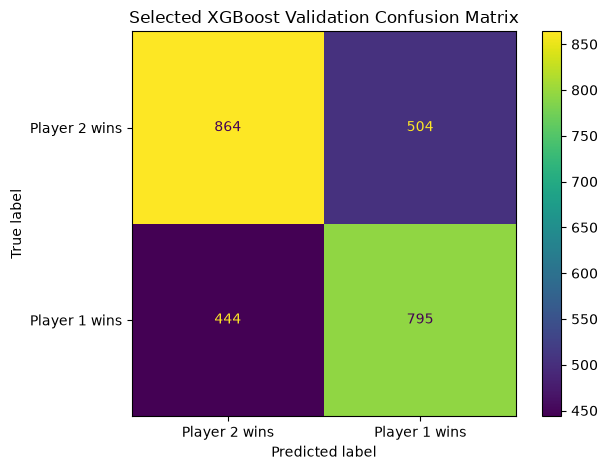

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_validation, 
    best_validation_predictions,
    display_labels=[
        "Player 2 wins",
        "Player 1 wins"
    ],
    
    values_format="d"
)

plt.title("Selected XGBoost Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## Feature Importance

In [23]:
xgboost_feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_ #assigns an importance value to each input feature.
        #The values add approximately to 1
    }
)

# Order the features from most important to least important.
xgboost_feature_importance = (
    xgboost_feature_importance.sort_values(
        by="Importance", ascending=False
    ).reset_index(drop=True)
)
xgboost_feature_importance

,Feature,Importance
0,PointsDifference,0.261584
1,WinRateDifference,0.143982
2,SurfaceWinRateDifference,0.093345
3,RankDifference,0.072032
4,SurfaceMatchesDifference,0.056334
5,Series_Grand Slam,0.029853
6,Player1Rank,0.028366
7,Player2Points,0.027179
8,Player2SurfaceMatchesBefore,0.026937
9,Player1SurfaceMatchesBefore,0.025968


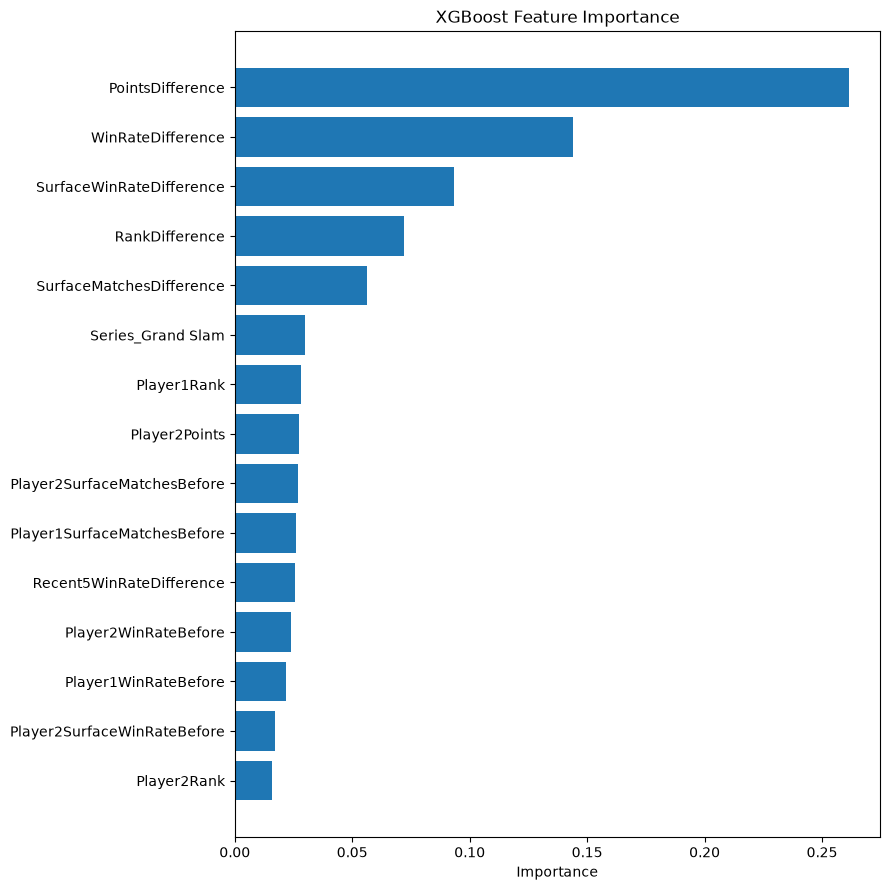

In [24]:
top_features = (
    xgboost_feature_importance.head(15).sort_values(
        by="Importance", ascending=True
    )
)

plt.figure(figsize=(9, 9))
plt.barh(
    top_features["Feature"], 
    top_features["Importance"]
)
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Tuning results table 
We tested eight parameter combinations using expanding temporal cross-validation and selected the configuration with the best mean validation accuracy.
This summary helps us understand if:
- increasing depth improve performance 
- what number of estimators work better, 200 or 100?
- if learning rate = 0.05 works better than 0.10

In [25]:
xgboost_cv_summary[
    [
        "MaxDepth",
        "NEstimators",
        "LearningRate",
        "MeanAccuracy",
        "StdAccuracy",
        "MeanROC_AUC",
        "MeanLogLoss"
    ]
]

,MaxDepth,NEstimators,LearningRate,MeanAccuracy,StdAccuracy,MeanROC_AUC,MeanLogLoss
0,2,200,0.05,0.642645,0.011140,0.703835,0.623975
1,2,100,0.10,0.642353,0.006982,0.703733,0.623957
2,3,100,0.10,0.641884,0.012208,0.703743,0.623992
3,3,200,0.05,0.641868,0.011852,0.703586,0.623634
4,3,100,0.05,0.641648,0.008827,0.703616,0.623498
5,2,100,0.05,0.640946,0.007575,0.701052,0.626136
6,3,200,0.10,0.640895,0.011017,0.698423,0.628787
7,2,200,0.10,0.638874,0.015012,0.703873,0.624160


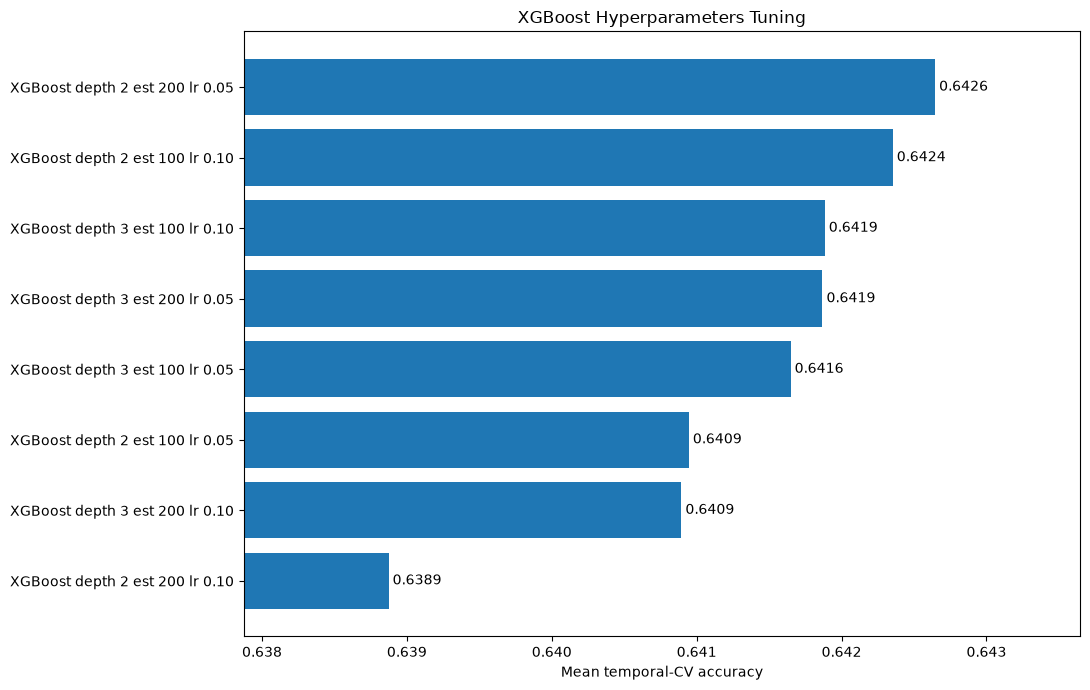

In [26]:
plot_data = (xgboost_cv_summary.sort_values(
    "MeanAccuracy", 
    ascending=True
))

min_accuracy = plot_data["MeanAccuracy"].min()
max_accuracy = plot_data["MeanAccuracy"].max()

difference = max_accuracy - min_accuracy

padding = max(
    difference*0.20,
    0.001
)

plt.figure(figsize=(11, 7))
bars = plt.barh(
    plot_data["Model"],
    plot_data["MeanAccuracy"]
)

plt.xlim(
    min_accuracy - padding,
    max_accuracy + padding
)

plt.xlabel("Mean temporal-CV accuracy")
plt.title("XGBoost Hyperparameters Tuning")

for bar, value in zip(
    bars, 
    plot_data["MeanAccuracy"]
):
    plt.text(
        value, 
        bar.get_y() + bar.get_height()/2, 
        f" {value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [27]:
MODEL_SELECTION_RESULTS_DIR = Path(
    "../results/model_selection"
)

VALIDATION_RESULTS_DIR = Path(
    "../results/validation"
)

FEATURE_IMPORTANCE_RESULTS_DIR = Path(
    "../results/feature_importance"
)

MODELS_DIR = Path("../models")

xgboost_cv_fold_results.to_csv(
    MODEL_SELECTION_RESULTS_DIR 
    / "xgboost_cv_fold_results.csv", 
    index=False
)

xgboost_cv_summary.to_csv(
    MODEL_SELECTION_RESULTS_DIR
    / "xgboost_cv_tuning_summary.csv", 
    index=False
)

xgboost_feature_importance.to_csv(
    FEATURE_IMPORTANCE_RESULTS_DIR 
    / "xgboost_feature_importance.csv", 
    index=False
)

best_xgboost_result.to_csv(
    VALIDATION_RESULTS_DIR
    / "best_xgboost_result.csv", 
    index=False
)

In [28]:
#save the model
import joblib 

joblib.dump(
    best_model, 
    MODELS_DIR / "best_xgboost_validation.joblib"
)

['..\\models\\best_xgboost_validation.joblib']

In [29]:
xgboost_preprocessing = {
    "numeric_medians":numeric_medians,
    "categorical_modes": categorical_modes,
    "one_hot_encoder": one_hot_encoder
}

In [30]:
joblib.dump(
    xgboost_preprocessing,
    MODELS_DIR / "xgboost_preprocessing.joblib"
)

['..\\models\\xgboost_preprocessing.joblib']

In [31]:
print( "XGBoost Temporal CV")

print(xgboost_cv_summary)

print(
    "\nSelected configuration:",
    best_configuration
)

print("\nExternal 2023 validation")
print(best_xgboost_result)

XGBoost Temporal CV
                             Model  MaxDepth  NEstimators  LearningRate  \
0  XGBoost depth 2 est 200 lr 0.05         2          200          0.05   
1  XGBoost depth 2 est 100 lr 0.10         2          100          0.10   
2  XGBoost depth 3 est 100 lr 0.10         3          100          0.10   
3  XGBoost depth 3 est 200 lr 0.05         3          200          0.05   
4  XGBoost depth 3 est 100 lr 0.05         3          100          0.05   
5  XGBoost depth 2 est 100 lr 0.05         2          100          0.05   
6  XGBoost depth 3 est 200 lr 0.10         3          200          0.10   
7  XGBoost depth 2 est 200 lr 0.10         2          200          0.10   

   MeanAccuracy  StdAccuracy  MeanBalancedAccuracy  MeanF1Score  MeanROC_AUC  \
0      0.642645     0.011140              0.642715     0.631841     0.703835   
1      0.642353     0.006982              0.642437     0.631549     0.703733   
2      0.641884     0.012208              0.641955     0.631416 

In [32]:
print("Top 15 features:")
print(xgboost_feature_importance.head(15))

Top 15 features:
                        Feature  Importance
0              PointsDifference    0.261584
1             WinRateDifference    0.143982
2      SurfaceWinRateDifference    0.093345
3                RankDifference    0.072032
4      SurfaceMatchesDifference    0.056334
5             Series_Grand Slam    0.029853
6                   Player1Rank    0.028366
7                 Player2Points    0.027179
8   Player2SurfaceMatchesBefore    0.026937
9   Player1SurfaceMatchesBefore    0.025968
10     Recent5WinRateDifference    0.025799
11         Player2WinRateBefore    0.024105
12         Player1WinRateBefore    0.021649
13  Player2SurfaceWinRateBefore    0.017209
14                  Player2Rank    0.015827
